# Flexible inference with `condition_on`

ProbPipe's central operation is `condition_on(model, data)`. The same function call works whether the inference engine underneath is NUTS, RWMH, neural posterior estimation, neural likelihood estimation plus MCMC, or sequential Monte Carlo ABC. ProbPipe inspects what the model supports (a combination of `SupportsLogProb`, `SupportsConditioning`, and `SupportsSampling`) and picks a registered method that can use it. We call this *protocol-based dispatch*, and the tutorial ends with a table showing how each engine below is reached from the same call site.

The running example is a small ecology problem. We use the **Ricker population model**, a discrete-time density-dependent growth model classic in fisheries and population biology. With deterministic dynamics, the likelihood is tractable and NUTS works fine. Flip on process noise and the likelihood becomes intractable, but the same class serves both regimes.

The engines we exercise:

- NUTS on the deterministic case, via `SimpleModel`.
- `sbi_learn_conditional` (NPE): amortized direct posterior sampling.
- `sbi_learn_likelihood` (NLE): emulated likelihood that any MCMC backend can drive.
- SMC-ABC via the inference registry.

> **Prerequisites:** [Getting Started tutorial](getting_started.ipynb). SBI features require `pip install probpipe[sbi]`.

In [1]:
import warnings; warnings.simplefilter('ignore')

import io
from contextlib import contextmanager, redirect_stderr, redirect_stdout

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
plt.rcParams['mathtext.default'] = 'regular'

from probpipe import (
    SimpleModel, SimpleGenerativeModel, Record, RecordArray,
    condition_on, sbi_learn_conditional, sbi_learn_likelihood,
    ProductDistribution, Normal,
)
from probpipe.modeling import Likelihood, GenerativeLikelihood


@contextmanager
def silence():
    """Suppress stdout/stderr chatter (tqdm bars, training logs)."""
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        yield

## 1. The Ricker population model

The Ricker map is a discrete-time density-dependent growth model with optional Gaussian process noise on the log-growth rate:

$$N_{t+1} = N_t \exp\!\left(r \left(1 - \frac{N_t}{K}\right) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

Observed counts are Poisson with rate $\phi N_t$:

$$y_t \mid N_t \sim \text{Poisson}(\phi N_t), \qquad t = 1, \ldots, T.$$

We work in log-space, $\theta = (\log r, \log K, \log \phi)$, so the prior is an independent product of normal distributions and all parameters stay positive after exponentiating. The noise scale $\sigma_p$ is a fixed setting of the model: $\sigma_p = 0$ gives the deterministic Ricker (closed-form likelihood) and any $\sigma_p > 0$ gives the stochastic Ricker (intractable likelihood). We defer the stochastic case to §5.

In [2]:
T = 40       # length of the observed time series
N0 = 5.0     # initial population size (assumed known)


class RickerObservationModel(Likelihood, GenerativeLikelihood):
    """Ricker population model with Poisson observations.

    Inheriting from both protocols makes it explicit that this class
    supplies the two APIs ProbPipe needs: ``log_likelihood`` (used by
    MCMC on a ``SimpleModel``) and ``generate_data`` (used by SBI on a
    ``SimpleGenerativeModel``).

    The ``sigma_p`` argument turns on Gaussian process noise on the
    log-growth rate.  For ``sigma_p == 0`` the trajectory is
    deterministic and ``log_likelihood`` is the exact Poisson log-pmf;
    for ``sigma_p > 0`` the latent ``N_t`` sequence is stochastic and
    the closed-form likelihood is no longer valid — ``log_likelihood``
    asserts on misuse, and only ``generate_data`` remains available.
    """

    def __init__(self, T, N0, sigma_p=0.0):
        self.T, self.N0, self.sigma_p = T, N0, sigma_p

    def _trajectory(self, params, key):
        # Sorted alphabetical order: K, phi, r
        K, phi, r = jnp.exp(params)
        noise = self.sigma_p * jax.random.normal(key, (self.T,))
        def step(N, eps):
            Nn = N * jnp.exp(r * (1 - N / K) + eps)
            return Nn, Nn
        _, traj = jax.lax.scan(step, self.N0, noise)
        return phi * traj

    def log_likelihood(self, params, data):
        assert self.sigma_p == 0, 'closed-form likelihood only valid for sigma_p=0'
        rates = self._trajectory(params, jax.random.PRNGKey(0))
        return jnp.sum(jax.scipy.stats.poisson.logpmf(data, rates))

    def generate_data(self, params, n_samples, *, key=None):
        if key is None:
            key = jax.random.PRNGKey(0)
        def one_sim(k):
            k_proc, k_obs = jax.random.split(k)
            return jax.random.poisson(
                k_obs, self._trajectory(params, k_proc)
            ).astype(jnp.float32)
        return jax.vmap(one_sim)(jax.random.split(key, n_samples))


ricker = RickerObservationModel(T=T, N0=N0)  # sigma_p=0 → deterministic
assert isinstance(ricker, Likelihood)
assert isinstance(ricker, GenerativeLikelihood)

### Generate the observed series

We pick "true" parameters $r = 1.8$, $K = 70$, $\phi = 10$, simulate one time series, and treat it as the dataset to be inferred.

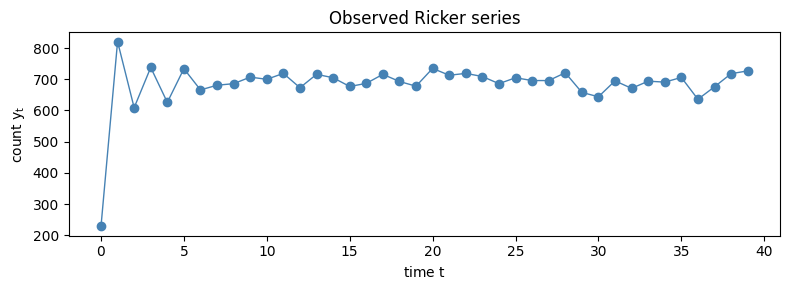

In [3]:
true_params = jnp.log(jnp.array([70.0, 10.0, 1.8]))  # K, phi, r (sorted)
true_params_nat = Record(K=70.0, phi=10.0, r=1.8)
y_obs = ricker.generate_data(true_params, 1, key=jax.random.PRNGKey(0))[0]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue', lw=1)
ax.set(xlabel='time $t$', ylabel='count $y_t$', title='Observed Ricker series')
plt.tight_layout(); plt.show()

### A loose log-space prior

We center each component in the right ballpark but deliberately off the truth, with moderate scale, so MCMC has real work to do. `ProductDistribution` defines an independent prior over named parameters. When all components are TFP-backed (as `Normal` is), `ProductDistribution` automatically exposes a combined TFP distribution for interop with SBI.

In [4]:
prior = ProductDistribution(K=Normal(loc=jnp.log(60.0), scale=0.3, name="K"),
                            phi=Normal(loc=jnp.log(8.0), scale=0.3, name="phi"),
                            r=Normal(loc=jnp.log(1.5), scale=0.4, name="r"))

## 2. MCMC via `condition_on`

Because we can write down a closed-form likelihood, the natural inference engine is MCMC. We package the prior and the likelihood in a `SimpleModel` and call `condition_on`. The model satisfies `SupportsLogProb`, so the inference registry auto-selects NUTS, exactly as in the Getting Started tutorial.

In [5]:
model_mcmc = SimpleModel(prior, ricker, name='ricker_mcmc')

posterior_mcmc = condition_on(model_mcmc, y_obs)
print(f'Algorithm: {posterior_mcmc.algorithm}')

Algorithm: tfp_nuts


In [6]:
PARAM_NAMES = ['r', 'K', 'phi']
truth_nat = {name: float(true_params_nat[name]) for name in PARAM_NAMES}


def _fmt(label, means, sds=None):
    sd_iter = sds if sds is not None else [None] * len(means)
    cols = '   '.join(
        f'{n} = {m:6.2f}' + (f' \u00b1 {s:5.2f}' if s is not None else ' ' * 8)
        for n, m, s in zip(PARAM_NAMES, means, sd_iter)
    )
    return f'{label:<26}{cols}'.rstrip()


def summarize(posterior, label):
    """Print ground truth and the (approximate) posterior mean +/- 2 sd."""
    draws = posterior.draws()
    if isinstance(draws, (Record, RecordArray)):
        nat = {name: np.exp(np.asarray(draws[name])) for name in PARAM_NAMES}
    else:
        flat = np.asarray(draws).reshape(-1, 3)
        # Flat array in sorted order: K=col0, phi=col1, r=col2
        nat = {'K': np.exp(flat[:, 0]), 'phi': np.exp(flat[:, 1]), 'r': np.exp(flat[:, 2])}
    means = [nat[n].mean() for n in PARAM_NAMES]
    sds = [2 * nat[n].std() for n in PARAM_NAMES]
    truths = [truth_nat[n] for n in PARAM_NAMES]
    print(_fmt('truth', truths))
    print(_fmt(label, means, sds))
    return nat


nat_mcmc = summarize(posterior_mcmc, 'NUTS (closed-form)')

truth                     r =   1.80           K =  70.00           phi =  10.00
NUTS (closed-form)        r =   1.81 ±  0.05   K =  78.65 ± 12.68   phi =   8.88 ±  1.41


## 3. What changes if you only have a simulator?

The Poisson-Ricker model above has a tractable likelihood because the dynamics are deterministic. Real ecological models almost never are: process noise, demographic stochasticity, individual-based simulators, or chaotic regimes ($r \gtrsim 2.5$ for Ricker) all destroy the closed-form likelihood. In those settings the only thing the user can supply is a simulator.

NUTS still works on the toy Ricker, so the point here is not that you *must* switch; it is that you *can*, without changing the model class or the call site:

```python
model_sim = SimpleGenerativeModel(prior, ricker)
posterior = condition_on(model_sim, y_obs, ...)
```

`SimpleGenerativeModel` only requires `generate_data`, never `log_likelihood`. Below we walk through three SBI engines, all reached through `condition_on`.

In [7]:
model_sim = SimpleGenerativeModel(prior, ricker, name='ricker_sim')

### 3a. Amortized neural posterior estimation

`sbi_learn_conditional` trains a neural density estimator (a masked autoregressive flow by default) to approximate $p(\theta \mid y)$ as a function of $y$. It returns a `DirectSamplerSBIModel` that implements `SupportsConditioning`, so `condition_on` calls the trained network directly with no MCMC step.

In [8]:
with silence():
    trained_npe = sbi_learn_conditional(prior, ricker, method='npe', n_simulations=5_000,
                                        n_iter=400, batch_size=128)
    posterior_npe = condition_on(trained_npe, y_obs)

nat_npe = summarize(posterior_npe, 'NPE (direct sampler)')

truth                     r =   1.80           K =  70.00           phi =  10.00
NPE (direct sampler)      r =   1.58 ±  0.29   K =  62.61 ± 36.74   phi =   8.36 ±  5.08


### 3b. Emulated likelihood + your favorite MCMC

`sbi_learn_likelihood` trains a neural network to approximate $p(y \mid \theta)$ instead of the posterior. The result is *just* a likelihood, so ProbPipe wraps it as a `SimpleModel(prior, neural_likelihood)` and `condition_on` dispatches through the standard inference registry. You can drive the emulated likelihood with NUTS, HMC, RWMH, nutpie, or any other registered MCMC backend.

`sbi_learn_likelihood` also has a `return_likelihood_only=True` mode that hands you just the `Likelihood` object, ready to combine with a different prior or feed into an `IncrementalConditioner` without re-training.

In [9]:
with silence():
    nle_model = sbi_learn_likelihood(prior, ricker, method='nle', n_simulations=5_000,
                                     n_iter=400, batch_size=128)
    posterior_nle = condition_on(nle_model, y_obs, method='tfp_nuts')

nat_nle = summarize(posterior_nle, 'NLE + NUTS')

truth                     r =   1.80           K =  70.00           phi =  10.00
NLE + NUTS                r =   1.77 ±  0.16   K =  66.22 ± 38.11   phi =  10.40 ±  4.10


### 3c. Sequential Monte Carlo ABC

SMC-ABC is a non-amortized, likelihood-free method: it iteratively refines a particle approximation to the posterior using the simulator alone. ProbPipe registers `SbiSMCABCMethod` against `SimpleGenerativeModel`, so calling `condition_on` on `model_sim` with `method='sbijax_smcabc'` runs SMC-ABC. We supply problem-specific summary statistics (mean, standard deviation, lag-1 autocorrelation), since identity summaries don't work in $T = 40$ dimensions.

In [10]:
def ricker_summary(y):
    y = jnp.atleast_2d(y).astype(jnp.float32)
    m, s = y.mean(-1, keepdims=True), y.std(-1, keepdims=True)
    ac1 = jnp.mean((y[:,1:] - m) * (y[:,:-1] - m), -1, keepdims=True) / (s**2 + 1e-6)
    return jnp.concatenate([m, s, ac1], -1)


with silence():
    posterior_abc = condition_on(model_sim, y_obs, method='sbijax_smcabc',
                                 summary_fn=ricker_summary, n_rounds=4, n_particles=500)

nat_abc = summarize(posterior_abc, 'SMC-ABC (likelihood-free)')

truth                     r =   1.80           K =  70.00           phi =  10.00
SMC-ABC (likelihood-free) r =   1.45 ±  0.77   K =  71.85 ± 31.83   phi =   9.63 ±  4.30


## 4. Comparing the four posteriors

All four runs go through the same `condition_on` entry point, return `ApproximateDistribution` objects, and feed downstream operations (`mean`, `variance`, `sample`, `predictive_check`, ...) identically. NUTS is the gold standard here because we have a closed-form likelihood. The three SBI backends all concentrate near the truth with looser tails: they pay the cost of training a neural surrogate or matching summary statistics rather than evaluating the exact log-density.

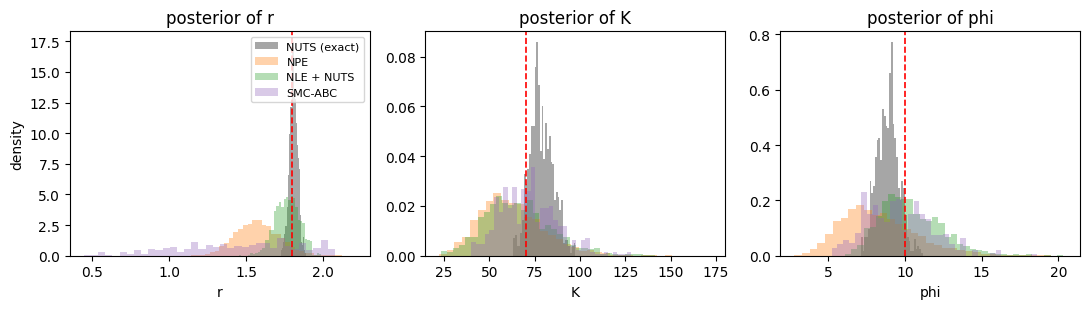

In [11]:
def plot_posteriors(posteriors, colors, truth_nat):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    for ax, name in zip(axes, PARAM_NAMES):
        for (label, nat), c in zip(posteriors.items(), colors):
            ax.hist(nat[name], bins=35, density=True, alpha=0.35, color=c, label=label)
        ax.axvline(truth_nat[name], color='red', ls='--', lw=1.2)
        ax.set(xlabel=name, ylabel='density' if name == PARAM_NAMES[0] else None,
               title=f'posterior of {name}')
    axes[0].legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()


plot_posteriors(
    {'NUTS (exact)': nat_mcmc, 'NPE': nat_npe, 'NLE + NUTS': nat_nle, 'SMC-ABC': nat_abc},
    ['black', 'tab:orange', 'tab:green', 'tab:purple'],
    truth_nat,
)

## 5. Flip the switch: stochastic Ricker

Setting `sigma_p > 0` on the *same class* adds Gaussian process noise to the log-growth rate, so each time step has a fresh shock:

$$N_{t+1} = N_t \exp\!\left(r (1 - N_t/K) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

Now $N_{1:T}$ is a latent stochastic process. The integral $p(y \mid \theta) = \int p(y \mid N_{1:T}) \, p(N_{1:T} \mid \theta) \, dN_{1:T}$ has no closed form, and the Poisson `log_likelihood` we used in §2 would silently return the wrong answer (it treats the noisy trajectory as if it were deterministic). We added an `assert sigma_p == 0` on `log_likelihood` to make that a loud failure rather than a quiet bias.

The simulator handles both regimes in the same code path, so the prior, the summary statistics, and the `condition_on` call site all carry over. The only difference from §3 is the model wrapper: `SimpleGenerativeModel` instead of `SimpleModel`, because there is no valid log-density to hand to MCMC.

log_likelihood refused:  closed-form likelihood only valid for sigma_p=0


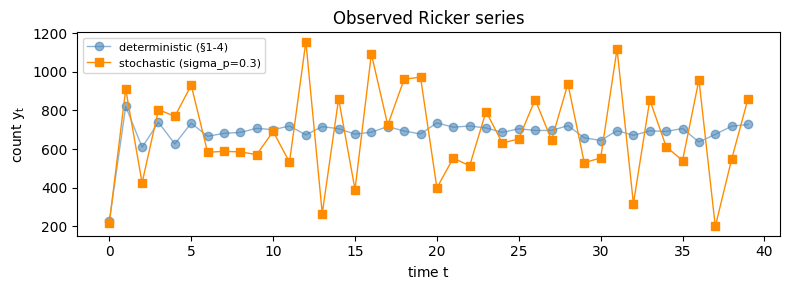

In [12]:
stoch_ricker = RickerObservationModel(T=T, N0=N0, sigma_p=0.3)

# Generate a fresh observed series from the stochastic model.
y_obs_stoch = stoch_ricker.generate_data(
    true_params, 1, key=jax.random.PRNGKey(7),
)[0]

# Protocol check: still a GenerativeLikelihood; log_likelihood now errors on use.
assert isinstance(stoch_ricker, GenerativeLikelihood)
try:
    stoch_ricker.log_likelihood(true_params, y_obs_stoch)
except AssertionError as e:
    print(f'log_likelihood refused:  {e}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue',
        lw=1, alpha=0.6, label='deterministic (§1-4)')
ax.plot(np.arange(T), np.asarray(y_obs_stoch), 's-', color='darkorange',
        lw=1, label='stochastic (sigma_p=0.3)')
ax.set(xlabel='time $t$', ylabel='count $y_t$', title='Observed Ricker series')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fit the stochastic model: only SBI is available

With no valid log-density we can't use `SimpleModel` + NUTS. We wrap the same class in `SimpleGenerativeModel` and run two SBI engines via `condition_on`: amortized NPE and SMC-ABC. The training and sampling code is identical to §3, just pointed at the stochastic model.

In [13]:
model_sim_stoch = SimpleGenerativeModel(prior, stoch_ricker)

with silence():
    trained_npe_stoch = sbi_learn_conditional(prior, stoch_ricker, method='npe',
                                              n_simulations=5_000, n_iter=400, batch_size=128)
    posterior_npe_stoch = condition_on(trained_npe_stoch, y_obs_stoch)

nat_npe_stoch = summarize(posterior_npe_stoch, 'NPE (stochastic)')

with silence():
    posterior_abc_stoch = condition_on(model_sim_stoch, y_obs_stoch, method='sbijax_smcabc',
                                       summary_fn=ricker_summary, n_rounds=4, n_particles=500)

nat_abc_stoch = summarize(posterior_abc_stoch, 'SMC-ABC (stochastic)')

truth                     r =   1.80           K =  70.00           phi =  10.00
NPE (stochastic)          r =   1.53 ±  0.63   K =  62.25 ± 37.24   phi =   8.17 ±  5.04


truth                     r =   1.80           K =  70.00           phi =  10.00
SMC-ABC (stochastic)      r =   1.46 ±  0.83   K =  72.68 ± 32.70   phi =   9.43 ±  4.25


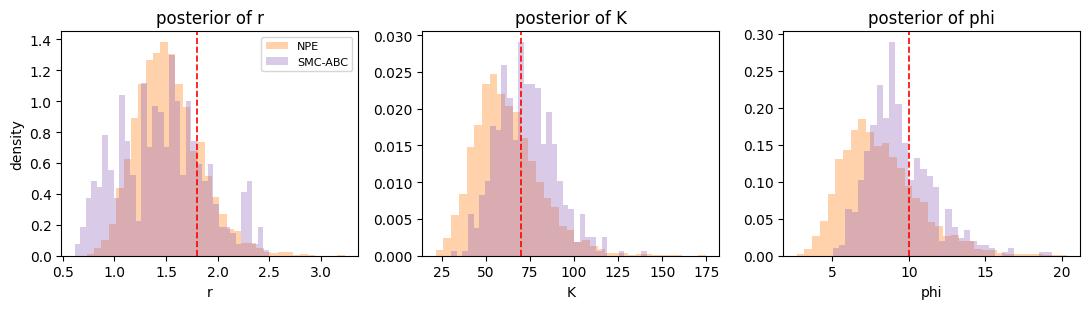

In [14]:
plot_posteriors(
    {'NPE': nat_npe_stoch, 'SMC-ABC': nat_abc_stoch},
    ['tab:orange', 'tab:purple'],
    truth_nat,
)

## 6. The unifying picture: protocol-based dispatch

The payoff of ProbPipe's protocol-driven design is that the model code never mentions an inference algorithm. Switching from NUTS to NPE to NLE-plus-NUTS to SMC-ABC is *one keyword argument*, or no argument at all (the registry picks for you). Section 5 showed that moving between the tractable and intractable regimes is literally one constructor argument (`sigma_p=0.3`) and one wrapper swap (`SimpleGenerativeModel` instead of `SimpleModel`). The rest of the workflow carries over unchanged: posteriors from all routes are interchangeable downstream, and the same `mean`, `variance`, predictive checks, uncertainty propagation, and provenance tracking apply.

Concretely, here is what `condition_on` dispatched to in each cell above:

| Model class | Protocols satisfied | `condition_on` dispatches to |
|---|---|---|
| `SimpleModel(prior, ricker)` | `SupportsLogProb` | NUTS (or HMC / RWMH / nutpie / ...) picked by the inference registry |
| `DirectSamplerSBIModel` (returned by `sbi_learn_conditional`) | `SupportsConditioning` | Direct call into the trained network; no registry lookup |
| `SimpleModel(prior, neural_likelihood)` (returned by `sbi_learn_likelihood`) | `SupportsLogProb` | Any registered MCMC backend, selected automatically or via `method=` |
| `SimpleGenerativeModel(prior, ricker)` | `SupportsSampling` on the prior only | `SbiSMCABCMethod`, registered under that model type |

Writing a new inference method is a matter of registering a class against a protocol signature; no existing model or call site needs to change.

### References

- Ricker, W.E. (1954). Stock and recruitment. *Journal of the Fisheries Research Board of Canada*, 11(5), 559–623.
- Wood, S.N. (2010). [Statistical inference for noisy nonlinear ecological dynamic systems](https://doi.org/10.1038/nature09319). *Nature*, 466, 1102–1104.
- Cranmer, K., Brehmer, J. & Louppe, G. (2020). [The frontier of simulation-based inference](https://doi.org/10.1073/pnas.1912789117). *PNAS*, 117(48), 30055–30062.
- Papamakarios, G. & Murray, I. (2016). [Fast ε-free inference of simulation models with Bayesian conditional density estimation](https://papers.nips.cc/paper/6084). *NeurIPS 2016*.
- Sisson, S.A., Fan, Y. & Beaumont, M.A. (2007). [Sequential Monte Carlo without likelihoods](https://doi.org/10.1073/pnas.0607208104). *PNAS*, 104(6), 1760–1765.

## Next steps

- [**API Reference**](../api/inference.md) — full list of registered inference methods, model wrappers, and the `condition_on` operation.
- [**Reference Notebooks**](../reference_notebooks.md) — focused examples for individual features.